<a href="https://colab.research.google.com/github/genasalah/Genaa/blob/main/BeachSaver_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Extract the dataset
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
   creating: sonar_dataset_4class/
   creating: sonar_dataset_4class/fish/
  inflating: sonar_dataset_4class/fish/fish_0.png  
  inflating: sonar_dataset_4class/fish/fish_1.png  
  inflating: sonar_dataset_4class/fish/fish_10.png  
  inflating: sonar_dataset_4class/fish/fish_100.png  
  inflating: sonar_dataset_4class/fish/fish_101.png  
  inflating: sonar_dataset_4class/fish/fish_102.png  
  inflating: sonar_dataset_4class/fish/fish_103.png  
  inflating: sonar_dataset_4class/fish/fish_104.png  
  inflating: sonar_dataset_4class/fish/fish_105.png  
  inflating: sonar_dataset_4class/fish/fish_106.png  
  inflating: sonar_dataset_4class/fish/fish_107.png  
  inflating: sonar_dataset_4class/fish/fish_108.png  
  inflating: sonar_dataset_4class/fish/fish_109.png  
  inflating: sonar_dataset_4class/fish/fish_11.png  
  inflating: sonar_dataset_4class/fish/fish_110.png  
  inflating: sonar_dataset_4class/fish/fish_111.png  
  inflating: sonar_dataset_4class/fi

In [34]:
# Libraries Import
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import smtplib
from email.message import EmailMessage
import gradio as gr
import numpy as np
from PIL import Image

Found 995 files belonging to 4 classes.
Using 796 files for training.
Found 995 files belonging to 4 classes.
Using 199 files for validation.
Starting Training with Early Stopping...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 530ms/step - accuracy: 0.5327 - loss: 1.1750 - val_accuracy: 0.7638 - val_loss: 0.7341
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 497ms/step - accuracy: 0.7450 - loss: 0.6376 - val_accuracy: 0.6633 - val_loss: 0.7336
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 516ms/step - accuracy: 0.7764 - loss: 0.5197 - val_accuracy: 0.8040 - val_loss: 0.4245
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.8518 - loss: 0.3719 - val_accuracy: 0.8492 - val_loss: 0.3313
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 637ms/step - accuracy: 0.8995 - loss: 0.2918 - val_accuracy: 0.8141 - val_loss: 0.4034
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 554ms/step - accuracy: 0.8945 - loss: 0.2956 - val_accuracy: 0.8744 - val_loss: 0.2867
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 4

Model trained and saved as sonar_model_final.h5


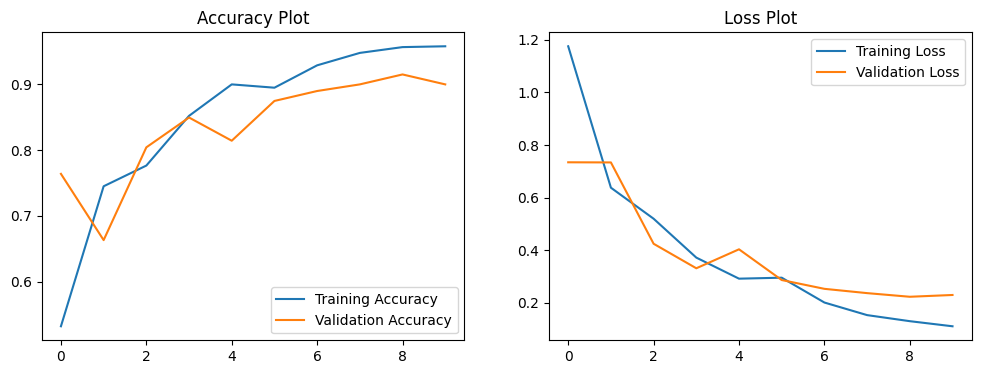

In [36]:
# Data Preprocessing
DATA_PATH = "/content/dataset"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

# Model Layers
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.GaussianNoise(0.1),
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping for avoiding Overfitting
early_stopping_monitor = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Training
print("Starting Training with Early Stopping...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping_monitor]
)

# Save the model
model.save('sonar_model.h5')
print("Model trained and saved as sonar_model_final.h5")

# Accuracy Charts
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Plot')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()

In [37]:
# Email Alert Function
def send_shark_alert(target_email, confidence_score):
    # Sender's email account information
    sender_email = "jwjwjynagena.com@gmail.com"
    app_password = "givk khdi xwqm mndq"

    msg = EmailMessage()

    # Email Message
    message_body = f"""
Dear Beach Safety Officer,

This is an automated emergency notification from the Beach Saver AI Monitoring System.

Our sonar analysis has just detected a potential shark in the monitored coastal zone. Please take immediate action to ensure public safety.

📊 Detection Details:
Object Identified: Shark (High Confidence)

Confidence Score: {confidence_score}

Status: Active Warning

🚨 Recommended Actions:
Clear all swimmers and divers from the water immediately.

Notify the nearest lifeguard station or coastal patrol.

Maintain a visual watch until the "All Clear" is issued.

Stay Safe,
Beach Saver Team
Automated Intelligence for Marine Safety
"""

    msg.set_content(message_body)

    msg['Subject'] = f"⚠️ URGENT: Shark Alert ({confidence_score} Confidence)"
    msg['From'] = f"Beach Saver System <{sender_email}>"
    msg['To'] = target_email

    # Sending Process
    try:
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as smtp:
            smtp.login(sender_email, app_password)
            smtp.send_message(msg)
        print(f"--- PROFESSIONAL ALERT SENT TO {target_email} [Conf: {confidence_score}] ---")
        return True
    except Exception as e:
        print(f"Email failed: {e}")
        return False

In [38]:
# Load the model
try:
    model = tf.keras.models.load_model('/content/sonar_model_final.h5')
    print("Model loaded successfully!")
except:
    print("Error: Model file not found. Please train the model first.")

# Classes
classes = ['fish', 'no_shark', 'rock', 'shark']

def predict_sonar(input_img, user_email):
    if input_img is None: return "Please upload an image."

    try:
        # Grayscale
        img = Image.fromarray(input_img.astype('uint8')).convert('L')
        img = img.resize((128, 128))

        # Rescaling Layer
        img_array = np.array(img).astype('float32')

        # Dimensions
        img_array = np.expand_dims(img_array, axis=-1)
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        predictions = model.predict(img_array)

        idx = np.argmax(predictions)
        score = float(predictions[0][idx])
        label = classes[idx]

        formatted_score = f"{score:.2%}"

        # Email Alert
        status = ""
        if label == "shark" and score > 0.8:
            if user_email and "@" in user_email:
                success = send_shark_alert(user_email, formatted_score)
                status = " | 📧 ALERT SENT" if success else " | ❌ MAIL FAILED"
            else:
                status = " | ⚠️ ENTER EMAIL"

        return f"Result: {label.upper()} (Confidence: {formatted_score}){status}"

    except Exception as e:
        return f"Error: {str(e)}"

# Gradio Interface
interface = gr.Interface(
    fn=predict_sonar,
    inputs=[
        gr.Image(label="Upload Sonar Image"),
        gr.Textbox(label="Alert Recipient Email", placeholder="your-email@example.com")
    ],
    outputs=gr.Textbox(label="Analysis Output"),
    title="Beach Saver - Sonar Monitoring System",
    description="Automated Shark Detection & Alert System."
)

if __name__ == "__main__":
    interface.launch()

Error: Model file not found. Please train the model first.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e47e69a363f05ba99.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
